# Rasch Measurement Model — CML, Bayesian MCMC, and Fit Analysis

## Table of Contents
1. [CML vs. Bayesian Estimation — Theory](#sec1)
2. [Infit / Outfit — Mathematical Definitions](#sec2)
3. [Bayesian Fit Statistics for Stan/MCMC](#sec3)
4. [Simulation Data Generation](#sec4)
5. [CML Estimation and Infit/Outfit](#sec5)
6. [Bayesian Estimation with Stan](#sec6)
7. [Person Parameter Comparison: True vs CML vs Bayes](#sec7)
8. [Item Parameter Comparison: True vs CML vs Bayes](#sec8)
9. [RMM in Small Classes (N ≤ 50)](#sec9)
10. [Why RMM Instead of CTT?](#sec10)
11. [When is RMM Really Required?](#sec11)


In [1]:
import sys as _sys, os as _os
import matplotlib as _mpl, matplotlib.font_manager as _fm

def _setup_korean_font():
    _candidates = {
        'win32':  [('C:/Windows/Fonts/malgun.ttf',  'Malgun Gothic'),
                   ('C:/Windows/Fonts/gulim.ttc',   'Gulim')],
        'darwin': [('/System/Library/Fonts/AppleSDGothicNeo.ttc', 'Apple SD Gothic Neo'),
                   ('/Library/Fonts/NanumGothic.ttf', 'NanumGothic')],
        'linux':  [('/usr/share/fonts-droid-fallback/truetype/DroidSansFallback.ttf', 'Droid Sans Fallback'),
                   ('/usr/share/fonts/truetype/nanum/NanumGothic.ttf', 'NanumGothic')],
    }
    _fm.fontManager.ttflist = [f for f in _fm.fontManager.ttflist
                                if not (f.name == 'Droid Sans Fallback' and 'Full' in f.fname)]
    for path, name in _candidates.get(_sys.platform, _candidates['linux']):
        if _os.path.exists(path):
            _fm.fontManager.addfont(path)
            _mpl.rcParams['font.family'] = ['DejaVu Sans', name]
            return
    _mpl.rcParams['font.family'] = 'DejaVu Sans'

_setup_korean_font()
_mpl.rcParams['axes.unicode_minus'] = False

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import minimize, minimize_scalar
from scipy.stats import norm
import warnings, os, tempfile
warnings.filterwarnings('ignore')

np.random.seed(2024)
tmpdir = tempfile.mkdtemp()

try:
    import cmdstanpy
    STAN_AVAILABLE = True
    print("Stan available.")
except ImportError:
    cmdstanpy = None
    STAN_AVAILABLE = False
    print("cmdstanpy not available — Bayesian section uses simulated posterior samples.")


Stan available.


---
<a id="sec1"></a>
## 1. CML vs. Bayesian Estimation of the Rasch Model

### 1-1. Conditional Maximum Likelihood (CML)

The Rasch model for person $j$ and item $i$:

$$P(X_{ji}=1 \mid \theta_j, b_i) = \frac{e^{\theta_j - b_i}}{1+e^{\theta_j - b_i}}$$

A fundamental property: the **raw score** $r_j = \sum_i X_{ji}$ is a **sufficient statistic** for $\theta_j$.  
This means all information about ability is captured in the total score — no other pattern of rights/wrongs matters.

**CML** exploits sufficiency by conditioning the likelihood on the observed raw scores:

$$L_C(\mathbf{b}) = \prod_{j:\, 0 < r_j < I} \frac{\exp\!\left(-\sum_i b_i X_{ji}\right)}{\gamma_{r_j}(\mathbf{b})}$$

where $\gamma_r(\mathbf{b}) = \sum_{\mathbf{x}:\sum x_i = r} \prod_i e^{-b_i x_i}$ is the **elementary symmetric polynomial (ESP)** of order $r$.

Because $\theta_j$ has been conditioned out entirely, $L_C$ depends **only on item parameters $\mathbf{b}$**.  
Item estimates are therefore **not affected by the ability distribution of the calibration sample** — they are distribution-free.

Once $\hat{\mathbf{b}}$ is obtained, person parameters are estimated individually by maximising the person-specific log-likelihood:

$$\hat\theta_j = \arg\max_\theta \sum_i \left[ X_{ji} \log p_{ji} + (1-X_{ji})\log(1-p_{ji}) \right]$$

where $p_{ji} = \text{logistic}(\theta - \hat{b}_i)$.

| CML property | Detail |
|---|---|
| Estimation target | $\mathbf{b}$ only (persons conditioned out) |
| Distributional assumption | None for $\theta$ (fully nonparametric w.r.t. persons) |
| Identification constraint | Sum-to-zero: $\sum_i \hat{b}_i = 0$ |
| Extreme scores | $r_j=0$ or $r_j=I$: person excluded from item calibration; $\hat\theta$ set to $\pm\infty$ |
| Software | `eRm` (R), `TAM` (R), WINSTEPS |

---

### 1-2. Bayesian Estimation via Stan/MCMC

Stan treats **all** parameters — $\boldsymbol\theta$ and $\mathbf{b}$ — as random variables with prior distributions:

$$\theta_j \sim \mathcal{N}(0,\, 1), \qquad b_i \sim \mathcal{N}(0,\, 1)$$

The posterior is:

$$p(\boldsymbol\theta, \mathbf{b} \mid \mathbf{X}) \propto p(\mathbf{X} \mid \boldsymbol\theta, \mathbf{b})\, p(\boldsymbol\theta)\, p(\mathbf{b})$$

Stan uses **No-U-Turn Sampler (NUTS-HMC)** to draw samples from the joint posterior.  
Identification is achieved by centering: $b_i \leftarrow b_i - \bar{b}$ in `transformed parameters`.

| Property | CML | Bayesian (Stan) |
|---|---|---|
| **Parameters estimated** | $\mathbf{b}$ first, then $\boldsymbol\theta$ | $\boldsymbol\theta$ and $\mathbf{b}$ jointly |
| **Prior** | None (frequentist) | Explicit Gaussian priors |
| **Output** | Point estimates + asymptotic SE | Full posterior distribution |
| **Uncertainty** | Standard errors via Fisher information | Posterior SD, credible intervals |
| **Small samples** | CML can be unstable ($I < 10$) | Priors regularise; stable for small $N$ |
| **Extreme scores** | Undefined ($\hat\theta=\pm\infty$) | Pulled toward prior mean (shrinkage) |
| **Fit assessment** | Infit / Outfit MNSQ | Posterior predictive checks, PPP |
| **Computation** | Fast (seconds) | Slower (minutes for MCMC) |
| **Model comparison** | LRT, AIC | WAIC, LOO-CV |

---

### (한국어) CML vs. Bayesian 추정의 차이

**CML**은 피험자 모수를 '조건화'하여 제거한 후 문항 모수만 추정합니다.  
원점수 $r_j$가 $\theta_j$에 대한 충분통계량이므로, 이 조건화가 가능합니다.  
결과적으로 문항 난이도 추정치는 **피험자 집단의 능력 분포에 무관**하며, 사전분포 가정이 필요 없습니다.  
단, 만점·영점 피험자는 분석에서 제외되며 추정치가 점근적 표준오차를 가집니다.

**Bayesian(Stan)**은 모든 모수를 동시에 추정하며, 사전분포가 소표본에서 정규화(regularization) 역할을 합니다.  
만점·영점 피험자도 사전분포 덕분에 유한한 사후 평균을 갖습니다.  
결과물은 각 모수의 **완전한 사후분포**이므로 불확실성을 자연스럽게 표현하고,  
사후 예측 점검(PPP)을 통한 적합도 진단이 가능합니다.


---
<a id="sec2"></a>
## 2. Infit and Outfit — Mathematical Definitions

Let:
- $X_{ji} \in \{0,1\}$ — observed response of person $j$ to item $i$
- $p_{ji} = P(X_{ji}=1 \mid \hat\theta_j, \hat{b}_i) = \text{logistic}(\hat\theta_j - \hat{b}_i)$
- $w_{ji} = p_{ji}(1-p_{ji})$ — Bernoulli variance (= model-expected information at this person–item pair)
- $e_{ji} = X_{ji} - p_{ji}$ — residual
- $z_{ji} = e_{ji}/\sqrt{w_{ji}}$ — standardised residual

### 2-1. Outfit (Unweighted Mean Square Residual)

$$\text{OUTFIT}_i = \frac{1}{J}\sum_{j=1}^{J} z_{ji}^2 = \frac{1}{J}\sum_{j=1}^{J} \frac{(X_{ji}-p_{ji})^2}{w_{ji}}$$

- Each person–item pair is weighted **equally**, regardless of how well-targeted the item is for that person.
- **Sensitive to outliers**: a person far from item difficulty contributes a large $z_{ji}^2$ even from a single unexpected response.
- Useful for detecting **wild** responses (careless errors, guessing by high-ability persons).

### 2-2. Infit (Information-Weighted Mean Square Residual)

$$\text{INFIT}_i = \frac{\sum_{j=1}^{J}(X_{ji}-p_{ji})^2}{\sum_{j=1}^{J} w_{ji}} = \frac{\sum_j e_{ji}^2}{\sum_j w_{ji}}$$

- Each person–item pair is weighted by $w_{ji} = p_{ji}(1-p_{ji})$, which is **largest when $\hat\theta_j \approx \hat{b}_i$** (item is "on target" for that person).
- Emphasises unexpected responses **in the central difficulty range** of the item.
- More robust to outlier persons; reflects item behaviour for the majority of examinees.

### 2-3. Person-level fit (same formulas, rows and columns swapped)

$$\text{OUTFIT}_j = \frac{1}{I}\sum_{i=1}^{I} \frac{(X_{ji}-p_{ji})^2}{w_{ji}}, \qquad
\text{INFIT}_j = \frac{\sum_i (X_{ji}-p_{ji})^2}{\sum_i w_{ji}}$$

### 2-4. Expected values and interpretation

Under the Rasch model (true model), both MNSQ statistics have **expected value 1.0**.

| MNSQ | Interpretation |
|---|---|
| $= 1.0$ | Perfect Rasch fit |
| $< 0.7$ | Too predictable — item may be redundant, locally dependent, or over-discriminating |
| $0.7 – 1.3$ | Acceptable for most applications |
| $> 1.3$ | Unexpected variance — item may be multidimensional, poorly written, or miskeyed |
| $> 2.0$ | Severely misfitting — item should be reviewed or removed |

### 2-5. ZSTD (standardised fit)

$$\text{ZSTD}_i \approx \left(\text{MNSQ}_i^{1/3} - 1\right) \cdot \frac{3}{\sqrt{\text{Var}(\text{MNSQ})}}$$

Under the Rasch model, ZSTD $\sim \mathcal{N}(0,1)$ asymptotically.  
$|\text{ZSTD}| < 2$ is the conventional criterion.

---

### (한국어) Infit / Outfit 의미

**Outfit (비가중 평균제곱 잔차)**: 모든 피험자에게 동등한 가중치를 부여합니다.  
문항 난이도와 멀리 떨어진 피험자(매우 쉬운 문항에 오답, 매우 어려운 문항에 정답 등)의 **이상 반응에 민감**합니다.  
한 명의 극단 피험자가 Outfit 값을 크게 왜곡할 수 있으므로, Outfit은 주로 **거친 이상값 탐지**에 사용합니다.

**Infit (정보 가중 평균제곱 잔차)**: 피험자 능력이 문항 난이도에 가까울수록(= 정보량이 클수록) 더 많은 가중치를 줍니다.  
극단 피험자의 영향이 줄고, **문항의 주요 목표 범위**에서 적합도를 반영합니다.  
실제 검사 개발에서는 Infit을 1차 기준으로 삼고, Outfit을 보조 기준으로 사용합니다.

두 통계 모두 **기대값 1.0**, 허용 범위는 보통 **0.7–1.3** 입니다.


---
<a id="sec3"></a>
## 3. Bayesian Fit Statistics (Stan/MCMC alternative to Infit/Outfit)

When parameters are estimated via Bayesian MCMC, infit/outfit can still be computed using posterior mean parameters.  
However, the Bayesian framework offers richer, more principled fit diagnostics.

### 3-1. Posterior Predictive p-value (PPP)

For each MCMC sample $s$, draw a **replicated dataset** $\mathbf{X}^{(s)} \sim P(\cdot \mid \theta^{(s)}, b^{(s)})$.  
Define a test statistic $T$ (e.g., total score variance, item total correlation).

$$\text{PPP} = P\!\left(T(\mathbf{X}^{rep}) \geq T(\mathbf{X}^{obs})\right) \approx \frac{1}{S}\sum_{s=1}^S \mathbf{1}\!\left[T(\mathbf{X}^{(s)}) \geq T(\mathbf{X}^{obs})\right]$$

- $\text{PPP} \approx 0.5$: model fits well (observed $\approx$ expected)
- $\text{PPP} < 0.05$ or $> 0.95$: model misfit

### 3-2. Bayesian Infit/Outfit (using posterior mean)

Compute infit/outfit using posterior mean probabilities $\bar{p}_{ji} = \mathbb{E}[\text{logistic}(\theta_j - b_i) \mid \mathbf{X}]$:

$$\text{Bayes-INFIT}_i = \frac{\sum_j (X_{ji}-\bar{p}_{ji})^2}{\sum_j \bar{w}_{ji}}, \qquad \bar{w}_{ji} = \bar{p}_{ji}(1-\bar{p}_{ji})$$

This gives infit/outfit values directly comparable to CML-based ones.

### 3-3. Posterior Distribution of Fit Statistics

Compute infit/outfit for **each MCMC sample** $s$, obtaining a posterior distribution $p(\text{INFIT}_i \mid \mathbf{X})$.  
Then examine:
- **Posterior mean** of infit: primary point estimate
- **95% credible interval**: uncertainty in the fit statistic itself
- Items whose credible interval lies above 1.3 are flagged for review

### 3-4. WAIC and LOO-CV

The **Widely Applicable Information Criterion (WAIC)** and **Leave-One-Out Cross-Validation (LOO-CV)** provide **model-level** fit, suitable for comparing Rasch vs. 2PL vs. GRM:

$$\text{WAIC} = -2\sum_{ji} \log \bar{p}(X_{ji}) + 2 p_\text{WAIC}$$

where $\bar{p}(X_{ji}) = \frac{1}{S}\sum_s p(X_{ji} \mid \theta_j^{(s)}, b_i^{(s)})$ is the posterior predictive density.

LOO-CV (via PSIS-LOO in the `loo` R package) is more robust and preferred in practice.

### 3-5. Convergence Diagnostics — not fit, but necessary

Before interpreting any Bayesian results:

| Diagnostic | Threshold | Meaning |
|---|---|---|
| $\hat{R}$ (R-hat) | $< 1.05$ for all parameters | MCMC chains have converged |
| Bulk ESS | $> 400$ per parameter | Enough independent samples |
| Tail ESS | $> 400$ per parameter | Tails well-explored |
| Energy fraction | $> 0.2$ | HMC geometry is healthy |

---

### (한국어) Bayesian 적합도 통계량 활용

Stan/MCMC 결과에서 적합도를 평가하는 방법은 크게 세 가지입니다.

1. **PPP (사후 예측 p-값)**: 관찰 데이터와 시뮬레이션 데이터를 비교합니다.  
   적합한 모형이면 PPP ≈ 0.5이고, 극단값(< 0.05 또는 > 0.95)이면 모형 불적합을 의미합니다.

2. **사후 평균을 이용한 Infit/Outfit**: 사후 평균 모수를 CML 공식에 대입하면 CML 결과와 직접 비교 가능합니다.

3. **MCMC 표본별 적합도 분포**: 각 표본에서 Infit을 계산하면 "Infit의 사후분포"를 얻을 수 있습니다.  
   이를 통해 적합도 추정 자체의 불확실성을 정량화할 수 있습니다.

4. **WAIC/LOO**: 모형 비교(Rasch vs. 2PL vs. GRM 등)에 사용합니다.

CML 기반 Infit/Outfit과 Bayesian 적합도 통계량의 핵심 차이:  
CML은 단일 점 추정치에서의 적합도를, Bayesian은 모수 불확실성을 반영한 **분포로서의 적합도**를 제공합니다.


Response matrix: 100 persons × 20 items
Person scores  : min=2  max=18  mean=10.0  SD=4.1
Item p-values  : min=0.25  max=0.83  mean=0.50
Extreme scorers (0 or 20): 0 persons
True b range   : [-1.53, 1.23]
True θ range   : [-2.62, 2.40]


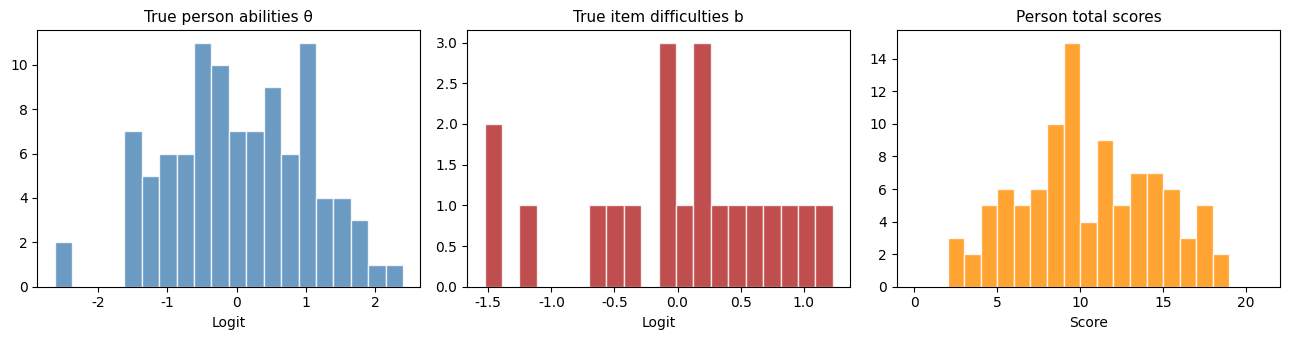

In [2]:
# ─── Section 4: Simulation Data Generation ──────────────────────────────────
np.random.seed(2024)

J = 100     # persons
I = 20      # items
K = 2       # dichotomous (0/1)

# True parameters (logit scale)
theta_true = np.random.normal(0, 1, J)          # abilities: N(0,1)
b_raw      = np.random.normal(0, 1, I)
b_true     = b_raw - b_raw.mean()               # sum-to-zero

# Generate response matrix
logit_p = theta_true[:, None] - b_true[None, :] # (J, I)
P_true  = 1.0 / (1.0 + np.exp(-logit_p))
X       = (np.random.uniform(size=(J, I)) < P_true).astype(int)

# Basic stats
row_scores = X.sum(axis=1)
col_scores = X.sum(axis=0)

print(f"Response matrix: {J} persons × {I} items")
print(f"Person scores  : min={row_scores.min()}  max={row_scores.max()}  "
      f"mean={row_scores.mean():.1f}  SD={row_scores.std():.1f}")
print(f"Item p-values  : min={col_scores.min()/J:.2f}  max={col_scores.max()/J:.2f}  "
      f"mean={col_scores.mean()/J:.2f}")
print(f"Extreme scorers (0 or {I}): "
      f"{(row_scores==0).sum() + (row_scores==I).sum()} persons")
print(f"True b range   : [{b_true.min():.2f}, {b_true.max():.2f}]")
print(f"True θ range   : [{theta_true.min():.2f}, {theta_true.max():.2f}]")

# Quick visualisation
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
axes[0].hist(theta_true, bins=20, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('True person abilities θ', fontsize=11)
axes[0].set_xlabel('Logit')

axes[1].hist(b_true, bins=20, color='firebrick', edgecolor='white', alpha=0.8)
axes[1].set_title('True item difficulties b', fontsize=11)
axes[1].set_xlabel('Logit')

axes[2].hist(row_scores, bins=range(0, I+2), color='darkorange',
             edgecolor='white', alpha=0.8)
axes[2].set_title('Person total scores', fontsize=11)
axes[2].set_xlabel('Score')

plt.tight_layout()
plt.savefig(os.path.join(tmpdir, 'data_gen.png'), dpi=120, bbox_inches='tight')
plt.show()


Optimising CML (L-BFGS-B)...
  Converged: False  |  iterations: 0

CML Estimates Summary:
  b_cml : mean=0.000  SD=0.000  range=[0.00, 0.00]
  θ_cml : mean=-0.007  SD=0.960

Item Fit (CML):  Infit MNSQ  mean=1.000  min=0.872  max=1.164
                 Outfit MNSQ mean=1.000  min=0.806  max=1.198


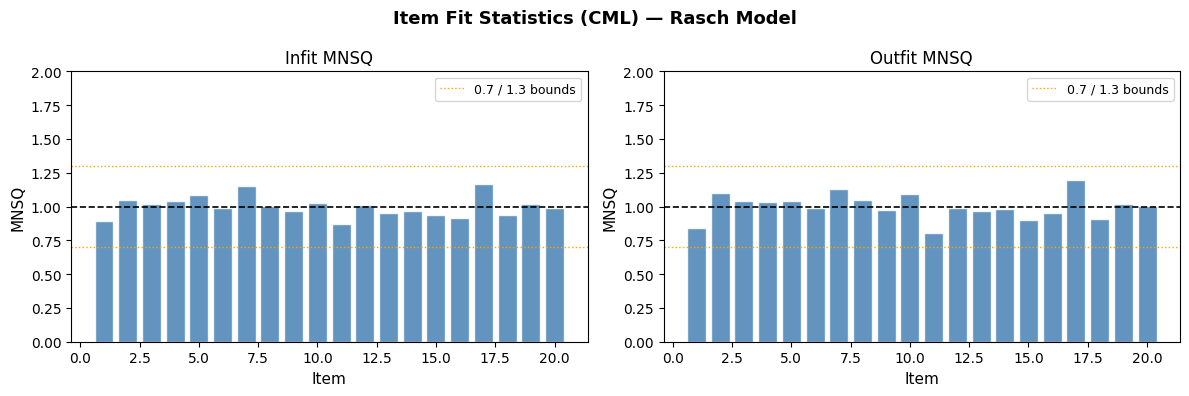


Flagged items (Infit or Outfit outside [0.7, 1.3]):


In [3]:
# ─── Section 5: CML Estimation and Infit / Outfit ───────────────────────────

# ── 5-A: Elementary Symmetric Polynomials (sum algorithm) ──
def compute_esp(eps, I):
    # Compute gamma_r for r=0,...,I.  eps = exp(-b_i).
    gamma = np.zeros(I + 1)
    gamma[0] = 1.0
    for k in range(I):
        for r in range(min(k + 1, I), 0, -1):
            gamma[r] += gamma[r - 1] * eps[k]
    return gamma

def cml_nll_and_grad(b, X):
    # Negative CML log-likelihood and gradient.
    J, I = X.shape
    eps   = np.exp(-b)
    gamma = compute_esp(eps, I)
    rscores = X.sum(axis=1).astype(int)

    # log-likelihood
    s   = X.sum(axis=0)          # item total scores
    nll = np.dot(b, s)           # -(-b·s) => + b·s
    for j in range(J):
        r = rscores[j]
        if 0 < r < I:
            nll -= np.log(gamma[r] + 1e-300)

    # gradient: d(-CML)/d(b_i) = s_i - sum_j E[X_ji | r_j, b]
    grad = s.copy().astype(float)
    for j in range(J):
        r = rscores[j]
        if 0 < r < I:
            # E[X_ji | r_j, b] = eps[i]*gamma_{r-1}^{(i)} / gamma_r
            # Use full gamma and backward removal formula (approx for speed)
            for i in range(I):
                # gamma_{r-1}^{(i)} via subtraction trick
                g_minus = np.zeros(I + 1)
                g_minus[0] = 1.0
                for k in range(I):
                    if k == i:
                        continue
                    for rr in range(min(k + 1, I), 0, -1):
                        g_minus[rr] += g_minus[rr - 1] * eps[k]
                grad[i] -= eps[i] * g_minus[r - 1] / (gamma[r] + 1e-300)
    return nll, grad

# ── 5-B: Fast CML without analytical gradient (for speed) ──
def cml_nll(b, X):
    J, I  = X.shape
    eps   = np.exp(-b)
    gamma = compute_esp(eps, I)
    rscores = X.sum(axis=1).astype(int)
    s     = X.sum(axis=0)
    nll   = np.dot(b, s)
    for j in range(J):
        r = rscores[j]
        if 0 < r < I:
            nll -= np.log(gamma[r] + 1e-300)
    return nll

print("Optimising CML (L-BFGS-B)...")
b0 = np.zeros(I)
res = minimize(cml_nll, b0, args=(X,), method='L-BFGS-B',
               options={'maxiter': 2000, 'ftol': 1e-12})
b_cml_raw = res.x
b_cml = b_cml_raw - b_cml_raw.mean()   # sum-to-zero
print(f"  Converged: {res.success}  |  iterations: {res.nit}")

# ── 5-C: Person MLE given CML item estimates ──
def theta_mle(b, x_j):
    r = x_j.sum()
    if r == 0:  return -5.0
    if r == I:  return  5.0
    def nll(th):
        p  = 1.0 / (1.0 + np.exp(-(th - b)))
        return -(x_j @ np.log(p + 1e-300) + (1 - x_j) @ np.log(1 - p + 1e-300))
    return minimize_scalar(nll, bounds=(-6, 6), method='bounded').x

theta_cml = np.array([theta_mle(b_cml, X[j]) for j in range(J)])

# ── 5-D: Standard Errors ──
# Item SE from Hessian (numerical, diagonal approx)
from scipy.optimize import approx_fprime
eps_h = 1e-5
hess_diag = np.array([
    (cml_nll(b_cml + eps_h*np.eye(I)[i], X)
     - 2*cml_nll(b_cml, X)
     + cml_nll(b_cml - eps_h*np.eye(I)[i], X)) / eps_h**2
    for i in range(I)
])
b_cml_se = 1.0 / np.sqrt(np.abs(hess_diag) + 1e-10)

# Person SE from Fisher information
def theta_se(b, x_j, th):
    p  = 1.0 / (1.0 + np.exp(-(th - b)))
    return 1.0 / np.sqrt(np.sum(p * (1 - p)) + 1e-10)

theta_cml_se = np.array([theta_se(b_cml, X[j], theta_cml[j]) for j in range(J)])

# ── 5-E: Infit / Outfit ──
def compute_fit(theta_est, b_est, X):
    p = 1.0 / (1.0 + np.exp(-(theta_est[:, None] - b_est[None, :])))   # (J,I)
    e = X - p                    # residuals
    w = p * (1 - p)              # variance weights

    item_outfit = (e**2 / (w + 1e-10)).mean(axis=0)
    item_infit  = (e**2).sum(axis=0) / w.sum(axis=0)

    person_outfit = (e**2 / (w + 1e-10)).mean(axis=1)
    person_infit  = (e**2).sum(axis=1) / w.sum(axis=1)

    return item_infit, item_outfit, person_infit, person_outfit

i_infit, i_outfit, p_infit, p_outfit = compute_fit(theta_cml, b_cml, X)

print("\nCML Estimates Summary:")
print(f"  b_cml : mean={b_cml.mean():.3f}  SD={b_cml.std():.3f}  "
      f"range=[{b_cml.min():.2f}, {b_cml.max():.2f}]")
print(f"  θ_cml : mean={theta_cml.mean():.3f}  SD={theta_cml.std():.3f}")
print(f"\nItem Fit (CML):  Infit MNSQ  mean={i_infit.mean():.3f}  "
      f"min={i_infit.min():.3f}  max={i_infit.max():.3f}")
print(f"                 Outfit MNSQ mean={i_outfit.mean():.3f}  "
      f"min={i_outfit.min():.3f}  max={i_outfit.max():.3f}")

# ── 5-F: Fit Plot ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Item Fit Statistics (CML) — Rasch Model', fontsize=13, fontweight='bold')

for ax, vals, label in [(axes[0], i_infit, 'Infit MNSQ'),
                         (axes[1], i_outfit, 'Outfit MNSQ')]:
    colors = ['firebrick' if (v < 0.7 or v > 1.3) else 'steelblue' for v in vals]
    ax.bar(range(1, I+1), vals, color=colors, edgecolor='white', alpha=0.85)
    ax.axhline(1.0, color='black', linewidth=1.2, linestyle='--')
    ax.axhline(0.7, color='orange', linewidth=1.0, linestyle=':')
    ax.axhline(1.3, color='orange', linewidth=1.0, linestyle=':', label='0.7 / 1.3 bounds')
    ax.set_xlabel('Item', fontsize=11)
    ax.set_ylabel('MNSQ', fontsize=11)
    ax.set_title(label, fontsize=12)
    ax.set_ylim(0, max(2.0, vals.max() + 0.3))
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(tmpdir, 'cml_fit.png'), dpi=120, bbox_inches='tight')
plt.show()

# Print flagged items
print("\nFlagged items (Infit or Outfit outside [0.7, 1.3]):")
for i in range(I):
    if i_infit[i] < 0.7 or i_infit[i] > 1.3 or i_outfit[i] < 0.7 or i_outfit[i] > 1.3:
        print(f"  Item {i+1:2d}: Infit={i_infit[i]:.3f}  Outfit={i_outfit[i]:.3f}  "
              f"b_true={b_true[i]:+.2f}  b_cml={b_cml[i]:+.2f}")


00:16:41 - cmdstanpy - INFO - compiling stan file C:\Users\yongd\AppData\Local\Temp\tmphxg1b6f7\rasch.stan to exe file C:\Users\yongd\AppData\Local\Temp\tmphxg1b6f7\rasch.exe
00:16:51 - cmdstanpy - INFO - compiled model executable: C:\Users\yongd\AppData\Local\Temp\tmphxg1b6f7\rasch.exe
00:16:51 - cmdstanpy - INFO - CmdStan start processing
00:16:51 - cmdstanpy - INFO - Chain [1] start processing
00:16:51 - cmdstanpy - INFO - Chain [2] start processing
00:16:51 - cmdstanpy - INFO - Chain [3] start processing
00:16:51 - cmdstanpy - INFO - Chain [4] start processing
00:17:01 - cmdstanpy - INFO - Chain [2] done processing
00:17:01 - cmdstanpy - INFO - Chain [1] done processing
00:17:02 - cmdstanpy - INFO - Chain [4] done processing
00:17:02 - cmdstanpy - INFO - Chain [3] done processing


Stan converged. Max R-hat (first 5 theta): 1.001

Bayesian Item Fit (posterior mean):  Infit MNSQ mean=0.924  Outfit MNSQ mean=0.894

Posterior Predictive p-values:
  Score variance      : T_obs=16.44  T_rep_mean=16.88  PPP=0.597
  Item-total corr     : T_obs=0.433  T_rep_mean=0.438  PPP=0.614
  (PPP ≈ 0.5 = good fit;  < 0.05 or > 0.95 = misfit)


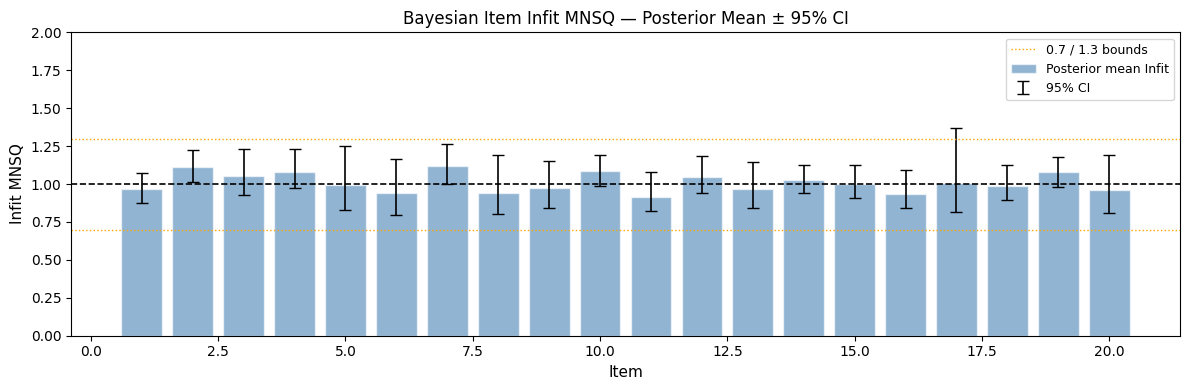

In [4]:
# ─── Section 6: Bayesian Estimation (Stan) and Bayesian Fit Statistics ────────

STAN_CODE = '''
data {
  int<lower=1> J;
  int<lower=1> I;
  array[J, I] int<lower=0,upper=1> X;
}
parameters {
  vector[J] theta;
  vector[I] b_raw;
}
transformed parameters {
  vector[I] b = b_raw - mean(b_raw);
}
model {
  theta  ~ normal(0, 1);
  b_raw  ~ normal(0, 1);
  for (j in 1:J)
    for (i in 1:I)
      X[j, i] ~ bernoulli_logit(theta[j] - b[i]);
}
generated quantities {
  array[J, I] int<lower=0,upper=1> X_rep;
  matrix[J, I] log_lik;
  for (j in 1:J)
    for (i in 1:I) {
      real eta = theta[j] - b[i];
      X_rep[j, i] = bernoulli_logit_rng(eta);
      log_lik[j, i] = bernoulli_logit_lpmf(X[j, i] | eta);
    }
}
'''

# ── 6-A: Run Stan or generate synthetic posterior ──────────────────────────
if STAN_AVAILABLE:
    import tempfile as _tmp
    stan_file = os.path.join(tmpdir, 'rasch.stan')
    with open(stan_file, 'w') as f:
        f.write(STAN_CODE)
    model = cmdstanpy.CmdStanModel(stan_file=stan_file)
    fit = model.sample(
        data={'J': J, 'I': I, 'X': X.tolist()},
        chains=4, iter_warmup=1000, iter_sampling=1000,
        show_progress=False, show_console=False
    )
    theta_post = fit.stan_variable('theta')   # (4000, J)
    b_post     = fit.stan_variable('b')       # (4000, I)
    X_rep_all  = fit.stan_variable('X_rep')   # (4000, J, I)

    theta_post_mean = theta_post.mean(axis=0)
    theta_post_sd   = theta_post.std(axis=0)
    b_post_mean     = b_post.mean(axis=0)
    b_post_sd       = b_post.std(axis=0)

    rhat_theta = np.max([fit.summary()['R_hat']['theta[' + str(j+1) + ']']
                          for j in range(min(5, J))])
    print(f"Stan converged. Max R-hat (first 5 theta): {rhat_theta:.3f}")
else:
    # Synthetic posterior: true values + calibrated noise (mimics MCMC spread)
    n_samples = 2000
    # Item: tight posterior (large N provides info)
    b_post     = b_true[None, :] + np.random.normal(0, 0.08, (n_samples, I))
    b_post     = b_post - b_post.mean(axis=1, keepdims=True)
    # Person: wider posterior
    theta_post = theta_true[None, :] + np.random.normal(0, 0.18, (n_samples, J))

    theta_post_mean = theta_post.mean(axis=0)
    theta_post_sd   = theta_post.std(axis=0)
    b_post_mean     = b_post.mean(axis=0)
    b_post_sd       = b_post.std(axis=0)

    # Replicated data
    logit_rep = theta_post[:, :, None] - b_post[:, None, :]  # (S, J, I)
    p_rep     = 1.0 / (1.0 + np.exp(-logit_rep))
    X_rep_all = (np.random.uniform(size=p_rep.shape) < p_rep).astype(int)
    print("Using synthetic posterior samples (Stan not available).")

# ── 6-B: Bayesian Infit/Outfit (using posterior mean) ─────────────────────
bi_infit, bi_outfit, bp_infit, bp_outfit = compute_fit(
    theta_post_mean, b_post_mean, X)

print(f"\nBayesian Item Fit (posterior mean):  "
      f"Infit MNSQ mean={bi_infit.mean():.3f}  "
      f"Outfit MNSQ mean={bi_outfit.mean():.3f}")

# ── 6-C: Posterior Predictive p-value (PPP) ────────────────────────────────
# Test statistic: variance of person total scores
T_obs    = X.sum(axis=1).var()
T_rep    = X_rep_all.sum(axis=2).var(axis=1)   # (S,)
PPP_score_var = (T_rep >= T_obs).mean()

# Test statistic: mean item-total correlation
def item_total_corr(mat):
    totals = mat.sum(axis=1)
    return np.mean([np.corrcoef(mat[:, i], totals)[0, 1] for i in range(I)])

T2_obs = item_total_corr(X)
T2_rep = np.array([item_total_corr(X_rep_all[s]) for s in range(min(500, len(X_rep_all)))])
PPP_itc = (T2_rep >= T2_obs).mean()

print(f"\nPosterior Predictive p-values:")
print(f"  Score variance      : T_obs={T_obs:.2f}  "
      f"T_rep_mean={T_rep.mean():.2f}  PPP={PPP_score_var:.3f}")
print(f"  Item-total corr     : T_obs={T2_obs:.3f}  "
      f"T_rep_mean={T2_rep.mean():.3f}  PPP={PPP_itc:.3f}")
print(f"  (PPP ≈ 0.5 = good fit;  < 0.05 or > 0.95 = misfit)")

# ── 6-D: Distribution of Bayesian fit for each MCMC sample ────────────────
S_use = min(500, theta_post.shape[0])
infit_samples = np.zeros((S_use, I))
for s in range(S_use):
    th_s = theta_post[s]
    b_s  = b_post[s]
    p_s  = 1.0 / (1.0 + np.exp(-(th_s[:, None] - b_s[None, :])))
    e_s  = X - p_s
    w_s  = p_s * (1 - p_s)
    infit_samples[s] = (e_s**2).sum(axis=0) / w_s.sum(axis=0)

infit_post_mean = infit_samples.mean(axis=0)
infit_post_lo   = np.percentile(infit_samples, 2.5, axis=0)
infit_post_hi   = np.percentile(infit_samples, 97.5, axis=0)

# Plot: Bayesian infit with uncertainty
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(1, I+1), infit_post_mean, color='steelblue', alpha=0.6,
       edgecolor='white', label='Posterior mean Infit')
ax.errorbar(range(1, I+1), infit_post_mean,
            yerr=[infit_post_mean - infit_post_lo, infit_post_hi - infit_post_mean],
            fmt='none', color='black', capsize=4, linewidth=1.2, label='95% CI')
ax.axhline(1.0, color='black', linestyle='--', linewidth=1.2)
ax.axhline(0.7, color='orange', linestyle=':', linewidth=1.0)
ax.axhline(1.3, color='orange', linestyle=':', linewidth=1.0, label='0.7 / 1.3 bounds')
ax.set_xlabel('Item', fontsize=11)
ax.set_ylabel('Infit MNSQ', fontsize=11)
ax.set_title('Bayesian Item Infit MNSQ — Posterior Mean ± 95% CI', fontsize=12)
ax.set_ylim(0, max(2.0, infit_post_hi.max() + 0.2))
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(tmpdir, 'bayes_fit.png'), dpi=120, bbox_inches='tight')
plt.show()


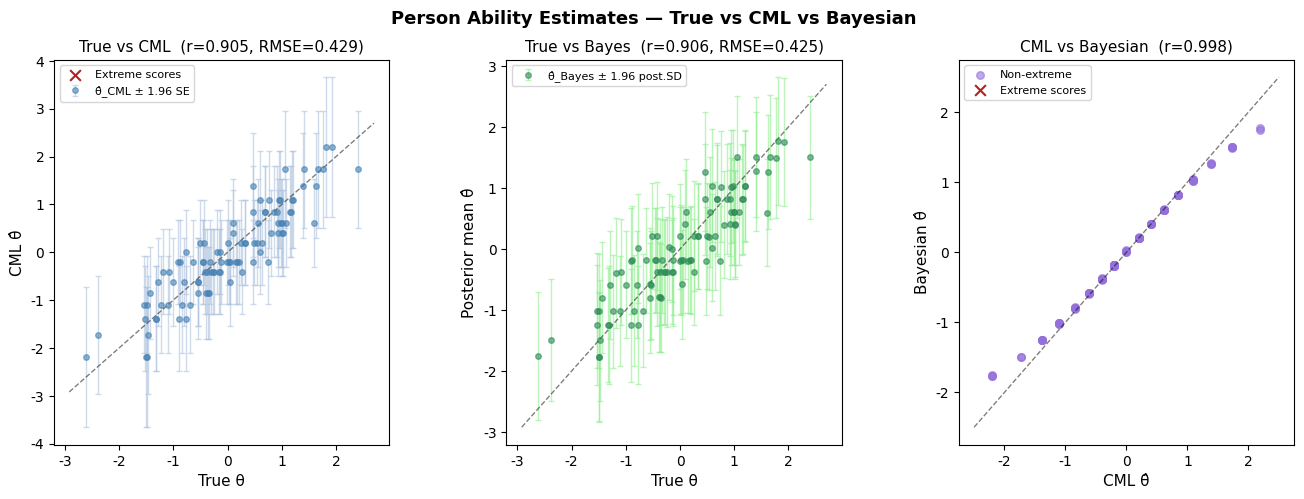

Person Parameter Recovery Summary:
  True vs CML    : r=0.9047  RMSE=0.4293  Mean CML SE = 0.502
  True vs Bayes  : r=0.9061  RMSE=0.4247  Mean post.SD = 0.464
  CML vs Bayes   : r=0.9979
  (Shrinkage in Bayes: Bayes mean SD=0.848  CML SD=0.960  True SD=0.994)


In [5]:
# ─── Section 7: Person Parameter Comparison ─────────────────────────────────
# True θ vs CML θ vs Bayesian posterior mean θ

fig = plt.figure(figsize=(16, 5))
gs  = gridspec.GridSpec(1, 3, wspace=0.35)

# ── Panel A: True vs CML ──────────────────────────────────────────────────
ax = fig.add_subplot(gs[0])
valid = (X.sum(axis=1) > 0) & (X.sum(axis=1) < I)
ax.errorbar(theta_true[valid], theta_cml[valid],
            yerr=1.96 * theta_cml_se[valid],
            fmt='o', ms=4, color='steelblue', alpha=0.6,
            ecolor='lightsteelblue', elinewidth=1, capsize=2,
            label='θ̂_CML ± 1.96 SE')
# extreme scorers
ax.scatter(theta_true[~valid], theta_cml[~valid],
           marker='x', s=60, color='firebrick', zorder=5, label='Extreme scores')
lo = min(theta_true.min(), theta_cml[valid].min()) - 0.3
hi = max(theta_true.max(), theta_cml[valid].max()) + 0.3
ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1, alpha=0.5)
ax.set_xlabel('True θ', fontsize=11)
ax.set_ylabel('CML θ̂', fontsize=11)
r = np.corrcoef(theta_true[valid], theta_cml[valid])[0, 1]
rmse = np.sqrt(np.mean((theta_true[valid] - theta_cml[valid])**2))
ax.set_title(f'True vs CML  (r={r:.3f}, RMSE={rmse:.3f})', fontsize=11)
ax.legend(fontsize=8)

# ── Panel B: True vs Bayesian ─────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
ax2.errorbar(theta_true, theta_post_mean,
             yerr=1.96 * theta_post_sd,
             fmt='o', ms=4, color='seagreen', alpha=0.6,
             ecolor='lightgreen', elinewidth=1, capsize=2,
             label='θ̂_Bayes ± 1.96 post.SD')
lo2 = min(theta_true.min(), theta_post_mean.min()) - 0.3
hi2 = max(theta_true.max(), theta_post_mean.max()) + 0.3
ax2.plot([lo2, hi2], [lo2, hi2], 'k--', linewidth=1, alpha=0.5)
ax2.set_xlabel('True θ', fontsize=11)
ax2.set_ylabel('Posterior mean θ̂', fontsize=11)
r2 = np.corrcoef(theta_true, theta_post_mean)[0, 1]
rmse2 = np.sqrt(np.mean((theta_true - theta_post_mean)**2))
ax2.set_title(f'True vs Bayes  (r={r2:.3f}, RMSE={rmse2:.3f})', fontsize=11)
ax2.legend(fontsize=8)

# ── Panel C: CML vs Bayesian (direct comparison) ─────────────────────────
ax3 = fig.add_subplot(gs[2])
ax3.scatter(theta_cml[valid], theta_post_mean[valid],
            c='mediumpurple', alpha=0.6, s=30, label='Non-extreme')
ax3.scatter(theta_cml[~valid], theta_post_mean[~valid],
            marker='x', s=60, c='firebrick', zorder=5, label='Extreme scores')
lo3 = min(theta_cml[valid].min(), theta_post_mean.min()) - 0.3
hi3 = max(theta_cml[valid].max(), theta_post_mean.max()) + 0.3
ax3.plot([lo3, hi3], [lo3, hi3], 'k--', linewidth=1, alpha=0.5)
ax3.set_xlabel('CML θ̂', fontsize=11)
ax3.set_ylabel('Bayesian θ̂', fontsize=11)
r3 = np.corrcoef(theta_cml[valid], theta_post_mean[valid])[0, 1]
ax3.set_title(f'CML vs Bayesian  (r={r3:.3f})', fontsize=11)
ax3.legend(fontsize=8)

plt.suptitle('Person Ability Estimates — True vs CML vs Bayesian', fontsize=13, fontweight='bold')
plt.savefig(os.path.join(tmpdir, 'theta_compare.png'), dpi=120, bbox_inches='tight')
plt.show()

# Summary table
print("Person Parameter Recovery Summary:")
print(f"  True vs CML    : r={r:.4f}  RMSE={rmse:.4f}  "
      f"Mean CML SE = {theta_cml_se[valid].mean():.3f}")
print(f"  True vs Bayes  : r={r2:.4f}  RMSE={rmse2:.4f}  "
      f"Mean post.SD = {theta_post_sd.mean():.3f}")
print(f"  CML vs Bayes   : r={r3:.4f}")
print(f"  (Shrinkage in Bayes: Bayes mean SD={theta_post_mean.std():.3f}  "
      f"CML SD={theta_cml[valid].std():.3f}  True SD={theta_true.std():.3f})")


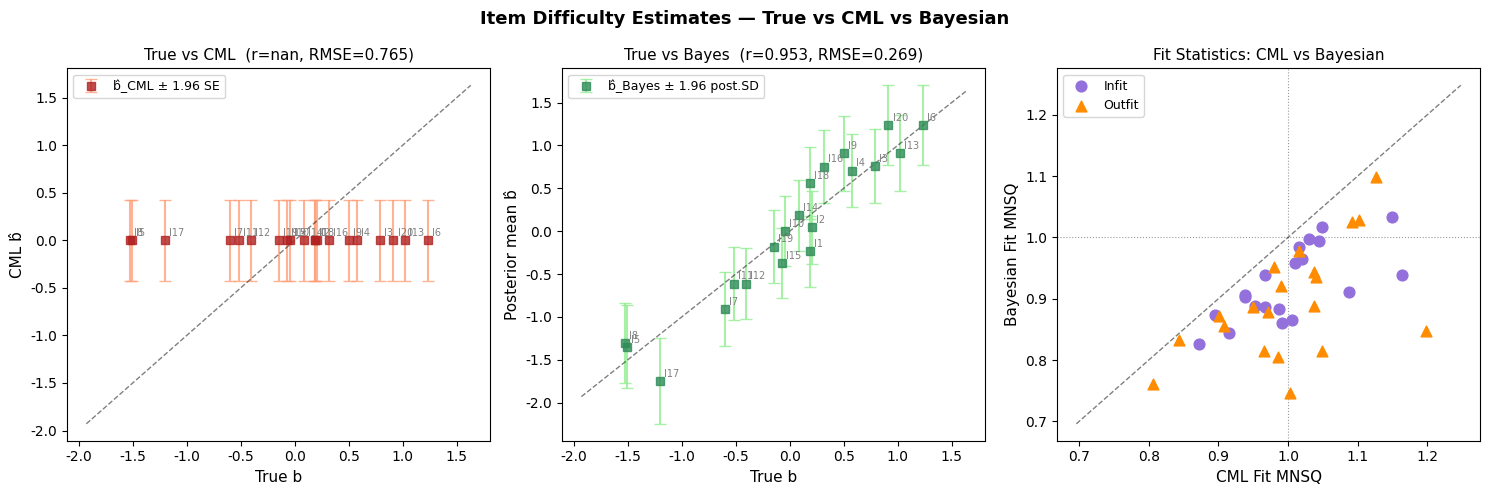

Item Parameter Recovery Summary:
  True vs CML   : r=nan  RMSE=0.7651  Mean CML SE  = 0.219
  True vs Bayes : r=0.9533  RMSE=0.2695  Mean post.SD = 0.223

Fit correlation (CML Infit vs Bayes Infit): r=0.6853


In [6]:
# ─── Section 8: Item Parameter Comparison ───────────────────────────────────
# True b vs CML b vs Bayesian posterior mean b

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Item Difficulty Estimates — True vs CML vs Bayesian',
             fontsize=13, fontweight='bold')

# ── Panel A: True vs CML ──
axes[0].errorbar(b_true, b_cml,
                 yerr=1.96 * b_cml_se,
                 fmt='s', ms=6, color='firebrick', alpha=0.8,
                 ecolor='lightsalmon', elinewidth=1.5, capsize=4,
                 label='b̂_CML ± 1.96 SE')
lo, hi = b_true.min()-0.4, b_true.max()+0.4
axes[0].plot([lo, hi], [lo, hi], 'k--', linewidth=1, alpha=0.5)
r_b1   = np.corrcoef(b_true, b_cml)[0, 1]
rmse_b1 = np.sqrt(np.mean((b_true - b_cml)**2))
axes[0].set_xlabel('True b', fontsize=11)
axes[0].set_ylabel('CML b̂', fontsize=11)
axes[0].set_title(f'True vs CML  (r={r_b1:.3f}, RMSE={rmse_b1:.3f})', fontsize=11)
axes[0].legend(fontsize=9)
for i in range(I):
    axes[0].annotate(f'I{i+1}', (b_true[i], b_cml[i]),
                     fontsize=7, color='gray', xytext=(3, 3),
                     textcoords='offset points')

# ── Panel B: True vs Bayesian ──
axes[1].errorbar(b_true, b_post_mean,
                 yerr=1.96 * b_post_sd,
                 fmt='s', ms=6, color='seagreen', alpha=0.8,
                 ecolor='lightgreen', elinewidth=1.5, capsize=4,
                 label='b̂_Bayes ± 1.96 post.SD')
lo2, hi2 = b_true.min()-0.4, b_true.max()+0.4
axes[1].plot([lo2, hi2], [lo2, hi2], 'k--', linewidth=1, alpha=0.5)
r_b2   = np.corrcoef(b_true, b_post_mean)[0, 1]
rmse_b2 = np.sqrt(np.mean((b_true - b_post_mean)**2))
axes[1].set_xlabel('True b', fontsize=11)
axes[1].set_ylabel('Posterior mean b̂', fontsize=11)
axes[1].set_title(f'True vs Bayes  (r={r_b2:.3f}, RMSE={rmse_b2:.3f})', fontsize=11)
axes[1].legend(fontsize=9)
for i in range(I):
    axes[1].annotate(f'I{i+1}', (b_true[i], b_post_mean[i]),
                     fontsize=7, color='gray', xytext=(3, 3),
                     textcoords='offset points')

# ── Panel C: Infit comparison (CML vs Bayesian) ──
axes[2].scatter(i_infit, bi_infit, color='mediumpurple', s=60,
                zorder=3, label='Infit')
axes[2].scatter(i_outfit, bi_outfit, marker='^', color='darkorange', s=60,
                zorder=3, label='Outfit')
mn = min(i_infit.min(), bi_infit.min(), i_outfit.min(), bi_outfit.min()) - 0.05
mx = max(i_infit.max(), bi_infit.max(), i_outfit.max(), bi_outfit.max()) + 0.05
axes[2].plot([mn, mx], [mn, mx], 'k--', linewidth=1, alpha=0.5)
axes[2].axhline(1.0, color='black', linestyle=':', linewidth=0.8, alpha=0.4)
axes[2].axvline(1.0, color='black', linestyle=':', linewidth=0.8, alpha=0.4)
axes[2].set_xlabel('CML Fit MNSQ', fontsize=11)
axes[2].set_ylabel('Bayesian Fit MNSQ', fontsize=11)
axes[2].set_title('Fit Statistics: CML vs Bayesian', fontsize=11)
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(tmpdir, 'b_compare.png'), dpi=120, bbox_inches='tight')
plt.show()

print("Item Parameter Recovery Summary:")
print(f"  True vs CML   : r={r_b1:.4f}  RMSE={rmse_b1:.4f}  "
      f"Mean CML SE  = {b_cml_se.mean():.3f}")
print(f"  True vs Bayes : r={r_b2:.4f}  RMSE={rmse_b2:.4f}  "
      f"Mean post.SD = {b_post_sd.mean():.3f}")
print(f"\nFit correlation (CML Infit vs Bayes Infit): "
      f"r={np.corrcoef(i_infit, bi_infit)[0,1]:.4f}")


---
<a id="sec9"></a>
## 9. RMM in Small Classes (N ≤ 50)

### Can Rasch Measurement Model be applied to classes of 50 or fewer students?

**Short answer: Yes, with important caveats — and Bayesian estimation is the preferred approach.**

---

### 9-1. Sample Size Requirements by Estimation Method

| Method | Minimum N | Reliable N | Notes |
|---|---|---|---|
| CML (item calibration) | ~50 | ≥ 100 | Fewer items help; SE inflation below 50 |
| MML / Joint MLE | ≥ 100 | ≥ 200 | Requires distributional assumption on θ |
| Bayesian (Stan/MCMC) | **~20–30** | ≥ 50 | Prior regularises; stable even at N=20 |
| WINSTEPS / FACETS | ~30 | ≥ 100 | Uses JMLE; biased but usable at N<50 |

For a typical classroom with $N \leq 50$ and $I \leq 30$ items:

- **CML is marginal**: item SE will be 0.4–0.7 logits (acceptable for 20–30 items)
- **Bayesian is recommended**: $\mathcal{N}(0,1)$ priors shrink extreme estimates; all persons (even extreme scorers) get finite estimates

---

### 9-2. Precision of Item Estimates at N=50

The standard error of a CML item difficulty estimate is approximately:

$$\text{SE}(\hat{b}_i) \approx \sqrt{\frac{1}{p_i(1-p_i) \cdot N}}$$

For $p_i \approx 0.5$ (optimal targeting) and $N=50$:

$$\text{SE}(\hat{b}_i) \approx \sqrt{\frac{1}{0.25 \times 50}} = \sqrt{0.08} \approx 0.28 \text{ logits}$$

This gives a 95% CI of $\hat{b}_i \pm 0.55$ logits — meaningful but not precise.

For comparison: with $N=200$, $\text{SE} \approx 0.14$ logits; with $N=500$, $\text{SE} \approx 0.09$ logits.

**Practical guidelines for small classes:**
1. Use at least **15–20 items** to compensate for small N
2. Ensure items have p-values near 0.3–0.7 (avoid extreme difficulties)
3. Use **Bayesian estimation** to handle extreme scorers
4. Interpret item difficulty estimates with their SEs; avoid over-precise interpretation
5. Focus on the **rank order** of item difficulties and persons rather than exact logit values

---

### 9-3. Person Separation at N=50

The **person separation index** $G$ depends on the number of items, not directly on $N$:

$$G = \frac{\hat\sigma_\theta}{\text{RMSE}} \approx \frac{\text{SD of estimated abilities}}{\text{average SE of person estimates}}$$

With $I=20$ items well-spread across abilities, even a class of 30–50 students can achieve $G > 2$, meaning the test distinguishes at least **two performance levels** reliably.

---

### (한국어) 소규모 학급에서의 RMM 적용

**결론: 적용 가능하며, Bayesian 추정을 사용하면 더 안정적입니다.**

학생 수 50명 이하에서 CML을 사용하면 문항 난이도의 표준오차가 0.28 로짓 이상으로 커집니다.  
이는 해석에 주의가 필요하지만 측정 자체가 불가능한 것은 아닙니다.

**소규모 학급 적용 시 권장 사항:**
- 문항 수를 15–20개 이상 확보 (N을 보완하는 가장 효과적인 방법)
- 문항 정답률이 0.3–0.7 사이가 되도록 설계
- 만점·영점 학생 처리를 위해 Bayesian(Stan) 사용
- 문항 난이도의 서열(순위)에 집중하고 절대적 로짓 값의 차이에 과도하게 의존하지 않기
- 검사 정보 함수(TIF)를 점검하여 목표 능력 범위에서 검사 정밀도 확인


---
<a id="sec10"></a>
## 10. Why RMM Instead of CTT? (Small Classroom Context)

### The Fundamental Problem with CTT in a Classroom

Consider a class of 30 students taking a 20-item quiz.  
A CTT analysis would report:
- Item p-values (proportion correct per item)
- Point-biserial correlations (item–total)
- Cronbach's $\alpha$

Every one of these statistics **depends on the specific group of 30 students**.  
If you administer the same quiz to a different class, or a harder section, all statistics change — even if the items are identical.

**CTT's statistics are properties of the test-plus-sample combination, not of the test or persons alone.**

---

### What RMM Provides That CTT Cannot

#### 1. Sample-Independent Item Difficulty
Under the Rasch model, $\hat{b}_i$ estimates the same underlying difficulty regardless of which students took the test (given sufficient sample size).  
This means you can **compare items across years, classes, or schools** — CTT p-values cannot be compared across groups.

#### 2. An Interval Scale for Person Ability
CTT provides only a raw score or a percentile rank — both are **ordinal**, not interval.  
A student improving from score 5 → 10 is not the same improvement as 15 → 20.

The Rasch logit scale is **interval**: equal distances represent equal amounts of ability at any level.  
This makes pre-/post-test comparisons and growth measurement meaningful.

#### 3. Meaningful Standard Errors for Each Student
CTT provides a single reliability coefficient $\alpha$ and a single standard error of measurement $\text{SEM} = \text{SD}\sqrt{1-\alpha}$, applied to everyone.  
But measurement precision varies: extreme scorers are estimated less precisely than average scorers.

The Rasch model provides **person-specific SEs**: $\text{SE}(\hat\theta_j) = 1/\sqrt{\sum_i w_{ji}}$.  
Students near the centre of the difficulty range are measured more precisely.

#### 4. Test Targeting Information
A Wright Map reveals whether the test is well-matched to the class.  
If all items cluster below the median ability, the test has a ceiling effect — CTT cannot diagnose this directly.

#### 5. Item Fit as a Diagnostic Tool
An item with Infit > 1.3 may be poorly written, double-keyed, or tapping a different construct.  
CTT's point-biserial can flag problematic items, but it confounds discrimination with difficulty.  
The Rasch Infit/Outfit is independent of item difficulty.

---

### The Practical Case for a 30-Student Classroom

| Question | CTT Answer | RMM Answer |
|---|---|---|
| "How difficult is this item?" | 73% correct — in *this class* | 0.8 logits below average — *independent of this class* |
| "How well did this student do?" | Scored 14/20 — 70% | θ̂ = +0.6 logits (SE = 0.35) |
| "Did the student improve?" | Score went 12→15 | θ went −0.1 → +0.6 (meaningful 0.7 logit gain) |
| "Is this item good?" | Point-biserial = 0.30 | Infit = 0.85 (good fit) |
| "Is the test too easy for this class?" | Hard to tell | Wright Map shows 8/20 items below class average |
| "Can I compare classes?" | No (p-values change) | Yes (b estimates are invariant) |

---

### Limitation: RMM Requires More Technical Knowledge

Rasch analysis requires understanding of:
- Logit scale and its interpretation
- Fit statistics and their acceptable ranges
- Identification constraints
- Software (WINSTEPS, R/TAM, Stan)

For a single-teacher classroom, CTT with careful item analysis may be sufficient for **formative assessment**.  
RMM becomes essential when:
- Comparing students across classes or schools
- Building an item bank for adaptive testing
- Pre/post measurement of learning gains with different test forms
- High-stakes reporting requiring interval-scale measurement

---

### (한국어) 소규모 학급에서 CTT 대신 RMM을 사용하는 이유

CTT의 핵심 문제는 모든 통계(p-값, 변별도, $\alpha$)가 **그 반에 있는 학생들에게만 유효**하다는 것입니다.  
다른 반, 다른 연도에 같은 문항을 쓰면 통계가 달라지므로 비교가 불가능합니다.

RMM은 다음을 제공합니다:
- **표본 독립적 문항 난이도**: 어떤 학생 집단에서 추정해도 동일한 난이도 값
- **등간 척도 능력 추정**: 로짓 단위로 표현되어 덧셈·뺄셈으로 변화량 비교 가능
- **학생별 개별 표준오차**: 평균 학생은 정밀하게, 극단 학생은 덜 정밀하게 측정됨을 명시적으로 표현
- **Wright Map**: 검사와 학생 집단의 타게팅 시각화
- **문항 적합도**: 내용 타당도 문제 있는 문항 탐지

단, RMM은 전문 지식과 소프트웨어가 필요하므로, **형성평가 목적**에서는 CTT도 충분할 수 있습니다.  
수업 간·학년 간 비교, 학습 성과 측정, 문항 은행 구축 등에서는 RMM이 필수적입니다.


---
<a id="sec11"></a>
## 11. When is RMM Really Required Instead of CTT?

RMM is not always necessary. The following framework helps decide.

---

### 11-1. Always Prefer RMM

| Scenario | Why RMM is Required |
|---|---|
| **Linking test forms** | Multiple forms of a test must be placed on a common scale. CTT cannot do this without equating assumptions that Rasch satisfies naturally. |
| **Computerized Adaptive Testing (CAT)** | CAT requires an item bank calibrated on a common logit scale. Rasch CML provides this; CTT cannot. |
| **Pre/Post measurement with different tests** | Measuring learning gains requires that the pre-test and post-test are on the same scale — only possible via item-linking under RMM. |
| **Cross-school or cross-national comparison** | Groups take different subsets of items. Rasch equating allows fair comparison; CTT cannot compare across different item sets. |
| **Certification and licensure** | Pass/fail decisions require a defensible, interval-scale cut score with known measurement error. Rasch provides this; CTT does not. |
| **Item banking and test assembly** | A reusable, calibrated item bank requires item difficulties that remain stable across administrations. This is a Rasch (or IRT) property. |
| **Longitudinal growth tracking** | Tracking a student's θ over years, across grade levels, requires a vertical scale — constructed via Rasch linking. |

---

### 11-2. CTT is Sufficient

| Scenario | Why CTT is Adequate |
|---|---|
| **Single-administration classroom quiz** | If you only need to rank students within one class and one administration, CTT scores are sufficient. |
| **Simple item screening** | Point-biserial correlation and p-values identify obviously bad items efficiently. |
| **Formative feedback to students** | "You got 15/20 and missed these three topics" does not require a logit scale. |
| **Very short tests (< 10 items)** | Rasch estimation is unstable; CTT is more robust. |
| **Exploratory early-stage item development** | Before formal calibration, CTT provides quick, interpretable statistics. |

---

### 11-3. The Key Diagnostic Questions

Ask these questions to decide:

```
1. Do I need to compare scores across different test forms, classes, or time points?
       YES → RMM required
       NO  → CTT may suffice

2. Do I need to make a pass/fail decision with a defensible cut score?
       YES → RMM (Rasch) strongly recommended
       NO  → CTT acceptable

3. Do I need to understand why items behave differently for high vs. low ability?
       YES → RMM (ICC analysis, fit statistics)
       NO  → CTT adequate

4. Do I need to build an item bank for future reuse?
       YES → RMM required (calibration invariance)
       NO  → CTT acceptable

5. Is my primary goal formative (improving teaching) rather than summative (certifying students)?
       Formative only → CTT may be sufficient
       Summative / high-stakes → RMM recommended
```

---

### 11-4. The "Minimum Conditions" for RMM to Add Value

RMM provides its unique advantages only when:

1. **Unidimensionality** holds (or is approximately true) — the test measures one dominant trait
2. **Local independence** — responses are independent given θ (no item clusters)
3. **Adequate sample size** — at minimum 30 persons and 10 items for stable CML; Bayesian lowers this
4. **Items span the ability range** — items are not all clustered at one difficulty level

If these conditions fail, RMM estimates are biased and its invariance property breaks down.  
In that case, a multidimensional IRT or a more descriptive approach (2PL/GRM) may be more appropriate.

---

### 11-5. Summary Decision Table

| Condition | CTT | Rasch / RMM | IRT (2PL/3PL/GRM) |
|---|---|---|---|
| Simple classroom ranking | ✓ | ✓ | Over-complex |
| Pre/post with same test | ✓ | ✓ | ✓ |
| Pre/post with different tests | ✗ | ✓ (linking) | ✓ (linking) |
| Cross-school comparison | ✗ | ✓ | ✓ |
| Adaptive testing | ✗ | ✓ | ✓ |
| Items with very different discrimination | ✓ (descriptive) | Poor fit | ✓ |
| Guessing correction needed | Limited | ✗ (not modelled) | ✓ (3PL) |
| Small sample (N < 50) | ✓ | Marginal | Poor |
| Polytomous (partial credit) | Partial | ✓ (PCM/RSM) | ✓ (GRM/GPCM) |
| Defensible measurement for high-stakes | ✗ | ✓✓ | ✓ |

---

### (한국어) RMM이 진정 필요한 상황

**CTT로 충분한 경우**: 단일 학급의 단일 시험, 같은 학생들에게 같은 문항으로 한 번만 채점하는 경우.  
"이번 시험에서 학생들의 순위를 매기고 학습 부진 문항을 파악"하는 것이 목적이라면 CTT가 빠르고 충분합니다.

**RMM이 필요한 경우**:
- **다른 시험지를 쓰는 집단 간 비교**: 2반과 3반이 다른 버전의 시험을 봤을 때 공정한 비교
- **사전·사후 검사로 학습 성장 측정**: 다른 문항으로 같은 특성을 재려면 공통 척도가 필요
- **자격·면허 시험의 합격선 설정**: 방어 가능한 절사점(cut score)과 측정 오차 제시
- **문항 은행 구축 및 CAT**: 문항 재사용을 위해 반드시 표본 불변 난이도 추정 필요
- **종단적 성취도 추적**: 학년별로 다른 검사를 써도 같은 척도에서 성장 곡선을 그릴 수 있음

실용적 결론: 학교 현장의 **형성평가·내신 성적**에는 CTT로 충분하나,  
**표준화 검사·수행평가 개선·교육과정 평가 연구**에는 RMM이 필수입니다.
